# Simultaneous multi-CNOT SPSA calibration and identifiability

Notebook 04 showed that all six CNOT controls are independently calibratable
when one active coordinate is known, but their passive syndrome signatures
span only three directions.  We now activate several calibration parameters
at the same time.

We track three different success criteria:

$$
L_{\mathrm{syn}}=1-P(00),
\qquad
E_\theta=\|\boldsymbol\theta\|_2,
\qquad
P_{\mathrm{logical}}.
$$

A low syndrome loss means that the **complete circuit** behaves correctly on
the calibration experiment.  It does not necessarily mean that every
individual gate parameter has been identified or returned to zero.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from qec_calibration import (  # noqa: E402
    CNOT_GATE_IDS,
    calibrate_cnot_parameters_spsa,
    logical_success_probability,
    normalized_single_fault_response_matrix,
    parameter_l2_norm,
    response_matrix_diagnostics,
    run_parameterized_recovery,
)


SEED = 42
DETAIL_MAXITER = 50
DETAIL_SHOTS = 2048
DETAIL_VALIDATION_SHOTS = 10_000
SCALING_MAXITER = 35
SCALING_SHOTS = 1024
SCALING_VALIDATION_SHOTS = 4096
SCALING_REPEATS = 3

## 1. Static information limit

The no-error syndrome distribution contains four probabilities satisfying
one normalization constraint.  Therefore it provides at most three
independent real numbers.  For the present model, the normalized single-
fault response matrix has exactly rank three.

This limits inversion of one fixed distribution.  It does not by itself
prohibit active optimization, because SPSA deliberately evaluates the
circuit at many controlled parameter vectors.

In [2]:
full_response = normalized_single_fault_response_matrix(0.6)
full_diagnostics = response_matrix_diagnostics(full_response)

print("Number of CNOT parameters:", len(CNOT_GATE_IDS))
print("Independent syndrome probabilities: 3")
print("Single-fault response rank:", full_diagnostics.rank)
print("Singular values:", np.round(full_diagnostics.singular_values, 6))

Number of CNOT parameters: 6
Independent syndrome probabilities: 3
Single-fault response rank: 3
Singular values: [2.901522 1.544918 1.092885 0.      ]


## 2. Two active gates with different signatures

`enc_01` transfers probability to `11`, while `syn_0a` transfers probability
to `10`.  Their response columns are independent, so both parameter
directions are visible in the syndrome distribution.

In [3]:
distinct_initial = {
    "enc_01": +0.6,
    "syn_0a": -0.5,
}
distinct_active = tuple(distinct_initial)

distinct_result = calibrate_cnot_parameters_spsa(
    initial_angles=distinct_initial,
    active_gate_ids=distinct_active,
    maxiter=DETAIL_MAXITER,
    shots_per_evaluation=DETAIL_SHOTS,
    validation_shots=DETAIL_VALIDATION_SHOTS,
    learning_rate=0.7,
    perturbation=0.12,
    seed=SEED,
)

distinct_table = pd.DataFrame(
    {
        "gate_id": distinct_active,
        "initial_angle": [
            distinct_result.initial_angles[gate_id]
            for gate_id in distinct_active
        ],
        "optimized_angle": [
            distinct_result.optimized_angles[gate_id]
            for gate_id in distinct_active
        ],
    }
)

print(f"Initial loss: {distinct_result.initial_loss:.6f}")
print(f"Final loss:   {distinct_result.validation_loss:.6f}")
print(
    "Initial parameter norm:",
    f"{parameter_l2_norm(distinct_result.initial_angles, distinct_active):.6f}",
)
print(
    "Final parameter norm:  ",
    f"{parameter_l2_norm(distinct_result.optimized_angles, distinct_active):.6f}",
)
distinct_table

Initial loss: 0.140600
Final loss:   0.000100
Initial parameter norm: 0.781025
Final parameter norm:   0.004425


,gate_id,initial_angle,optimized_angle
0,enc_01,0.6,0.00328
1,syn_0a,-0.5,-0.00297


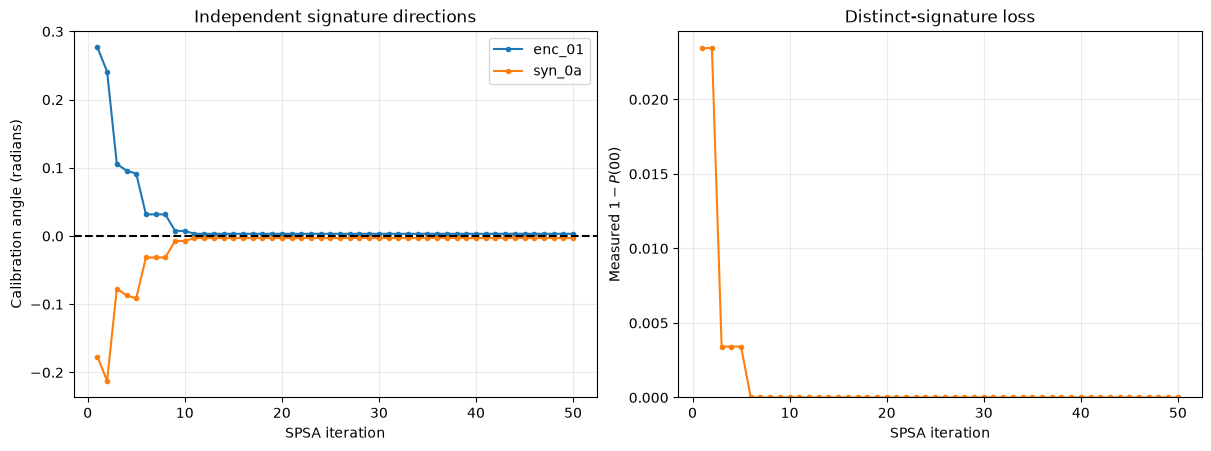

In [4]:
distinct_history = pd.DataFrame(distinct_result.iteration_history)
for index, gate_id in enumerate(distinct_active):
    distinct_history[gate_id] = distinct_history["active_values"].map(
        lambda values, i=index: values[i]
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), constrained_layout=True)
for gate_id in distinct_active:
    axes[0].plot(
        distinct_history["iteration"],
        distinct_history[gate_id],
        marker="o",
        markersize=3,
        label=gate_id,
    )
axes[0].axhline(0.0, color="black", linestyle="--")
axes[0].set(
    xlabel="SPSA iteration",
    ylabel="Calibration angle (radians)",
    title="Independent signature directions",
)
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(
    distinct_history["iteration"],
    distinct_history["loss"],
    marker="o",
    markersize=3,
    color="tab:orange",
)
axes[1].set(
    xlabel="SPSA iteration",
    ylabel=r"Measured $1-P(00)$",
    title="Distinct-signature loss",
)
axes[1].set_ylim(bottom=0)
axes[1].grid(alpha=0.25)
plt.show()

## 3. Two active gates with the same signature

`syn_0a` and `syn_0b` both leave a target rotation on ancilla 0.  An
$X$-axis rotation of the target commutes with a CNOT acting on that target,
so the two residual rotations combine:

$$
R_x(\theta_{0b})R_x(\theta_{0a})
=R_x(\theta_{0a}+\theta_{0b}).
$$

Consequently,

$$
L(\theta_{0a},\theta_{0b})
=\sin^2\!\left(\frac{\theta_{0a}+\theta_{0b}}{2}\right).
$$

The loss fixes the sum but is insensitive to the difference.  This creates
a flat line of global minima rather than one isolated optimum.

In [5]:
degenerate_initial = {
    "syn_0a": +0.6,
    "syn_0b": -0.5,
}
degenerate_active = tuple(degenerate_initial)

degenerate_result = calibrate_cnot_parameters_spsa(
    initial_angles=degenerate_initial,
    active_gate_ids=degenerate_active,
    maxiter=DETAIL_MAXITER,
    shots_per_evaluation=DETAIL_SHOTS,
    validation_shots=DETAIL_VALIDATION_SHOTS,
    learning_rate=0.7,
    perturbation=0.12,
    seed=SEED,
)

degenerate_initial_norm = parameter_l2_norm(
    degenerate_result.initial_angles,
    degenerate_active,
)
degenerate_final_norm = parameter_l2_norm(
    degenerate_result.optimized_angles,
    degenerate_active,
)

degenerate_table = pd.DataFrame(
    {
        "gate_id": degenerate_active,
        "initial_angle": [
            degenerate_result.initial_angles[gate_id]
            for gate_id in degenerate_active
        ],
        "optimized_angle": [
            degenerate_result.optimized_angles[gate_id]
            for gate_id in degenerate_active
        ],
    }
)

print(f"Initial loss: {degenerate_result.initial_loss:.6f}")
print(f"Final loss:   {degenerate_result.validation_loss:.6f}")
print(f"Initial norm: {degenerate_initial_norm:.6f}")
print(f"Final norm:   {degenerate_final_norm:.6f}")
print(
    "Final observable sum:",
    sum(degenerate_result.optimized_angles[g] for g in degenerate_active),
)
degenerate_table

Initial loss: 0.001900
Final loss:   0.000000
Initial norm: 0.781025
Final norm:   0.777817
Final observable sum: 0.0003092447916667185


,gate_id,initial_angle,optimized_angle
0,syn_0a,0.6,0.550155
1,syn_0b,-0.5,-0.549845


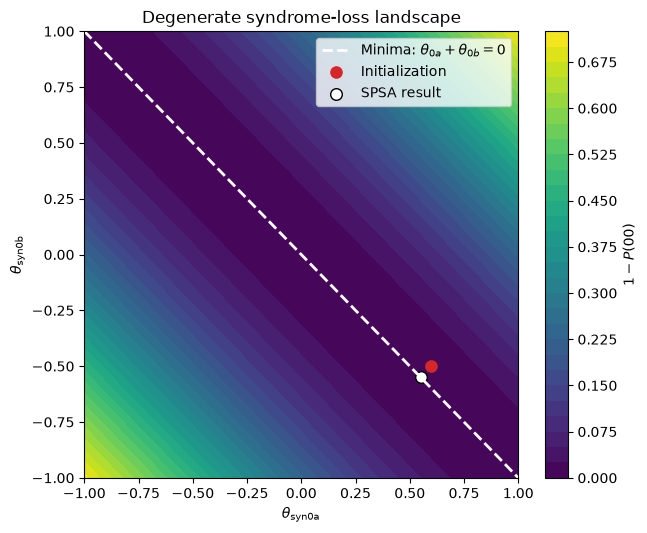

In [6]:
grid = np.linspace(-1.0, 1.0, 301)
theta_a, theta_b = np.meshgrid(grid, grid)
loss_surface = np.sin((theta_a + theta_b) / 2.0) ** 2

fig, ax = plt.subplots(figsize=(7, 5.8))
contour = ax.contourf(theta_a, theta_b, loss_surface, levels=30, cmap="viridis")
ax.plot(grid, -grid, "w--", linewidth=2, label=r"Minima: $\theta_{0a}+\theta_{0b}=0$")
ax.scatter(
    [degenerate_initial["syn_0a"]],
    [degenerate_initial["syn_0b"]],
    color="tab:red",
    s=65,
    label="Initialization",
)
ax.scatter(
    [degenerate_result.optimized_angles["syn_0a"]],
    [degenerate_result.optimized_angles["syn_0b"]],
    color="white",
    edgecolor="black",
    s=70,
    label="SPSA result",
)
ax.set(
    xlabel=r"$\theta_{\mathrm{syn0a}}$",
    ylabel=r"$\theta_{\mathrm{syn0b}}$",
    title="Degenerate syndrome-loss landscape",
)
ax.legend(loc="upper right")
fig.colorbar(contour, ax=ax, label=r"$1-P(00)$")
plt.show()

SPSA successfully calibrates the circuit-level observable, but it cannot
select the individual zero-angle solution from the entire line of equivalent
minima.  This is the first explicit example of

$$L_{\mathrm{syn}}\approx0
\quad\not\Rightarrow\quad
\|\boldsymbol\theta\|_2\approx0.$$

## 4. Increase the number of active parameters from one to six

The first three entries below are chosen from the three independent syndrome
classes.  Parameters four through six add columns that are already in the
span of the first three:

```text
enc_01  -> 11
syn_0a  -> 10
enc_02  -> 01
syn_0b  -> 10   (degenerate addition)
syn_1a  -> 01   (degenerate addition)
syn_1b  -> 01   (degenerate addition)
```

We run three seeded trials at every active-vector size.  These are
optimization experiments, not formal statistical confidence intervals.

In [7]:
scaling_order = (
    "enc_01",
    "syn_0a",
    "enc_02",
    "syn_0b",
    "syn_1a",
    "syn_1b",
)
base_initial_vector = np.asarray([0.6, -0.5, 0.4, -0.35, 0.3, -0.45])
scaling_rng = np.random.default_rng(314)

scaling_rows = []
scaling_results = {}

for parameter_count in range(1, len(scaling_order) + 1):
    active = scaling_order[:parameter_count]
    active_response = normalized_single_fault_response_matrix(
        0.6,
        gate_ids=active,
    )
    response_rank = response_matrix_diagnostics(active_response).rank

    for trial in range(SCALING_REPEATS):
        initial_values = (
            base_initial_vector[:parameter_count]
            + scaling_rng.normal(0.0, 0.04, parameter_count)
        )
        initial_angles = dict(zip(active, initial_values, strict=True))

        result = calibrate_cnot_parameters_spsa(
            initial_angles=initial_angles,
            active_gate_ids=active,
            maxiter=SCALING_MAXITER,
            shots_per_evaluation=SCALING_SHOTS,
            validation_shots=SCALING_VALIDATION_SHOTS,
            learning_rate=0.7,
            perturbation=0.12,
            seed=1000 + 100 * parameter_count + trial,
        )
        scaling_results[(parameter_count, trial)] = result
        scaling_rows.append(
            {
                "active_parameters": parameter_count,
                "response_rank": response_rank,
                "trial": trial,
                "initial_loss": result.initial_loss,
                "final_loss": result.validation_loss,
                "initial_parameter_norm": parameter_l2_norm(
                    result.initial_angles,
                    active,
                ),
                "final_parameter_norm": parameter_l2_norm(
                    result.optimized_angles,
                    active,
                ),
            }
        )

scaling_trials = pd.DataFrame(scaling_rows)
scaling_trials

,active_parameters,response_rank,trial,initial_loss,final_loss,initial_parameter_norm,final_parameter_norm
0,1,1,0,0.080811,0.000000,0.575071,0.011106
1,1,1,1,0.082275,0.000000,0.577748,0.000458
2,1,1,2,0.085205,0.000000,0.601496,0.011896
3,2,2,0,0.159424,0.000000,0.811294,0.001088
4,2,2,1,0.141846,0.000000,0.788439,0.002483
5,2,2,2,0.148438,0.000000,0.789500,0.005159
6,3,3,0,0.189697,0.000000,0.910718,0.003598
7,3,3,1,0.171875,0.000000,0.881556,0.002245
8,3,3,2,0.174072,0.000000,0.887745,0.012300
9,4,3,0,0.306885,0.000000,0.952999,0.240183


In [8]:
scaling_summary = (
    scaling_trials.groupby("active_parameters", sort=True)
    .agg(
        response_rank=("response_rank", "first"),
        median_initial_loss=("initial_loss", "median"),
        median_final_loss=("final_loss", "median"),
        min_final_loss=("final_loss", "min"),
        max_final_loss=("final_loss", "max"),
        median_initial_norm=("initial_parameter_norm", "median"),
        median_final_norm=("final_parameter_norm", "median"),
        min_final_norm=("final_parameter_norm", "min"),
        max_final_norm=("final_parameter_norm", "max"),
    )
    .reset_index()
)
scaling_summary["parameters_minus_rank"] = (
    scaling_summary["active_parameters"] - scaling_summary["response_rank"]
)
scaling_summary

,active_parameters,response_rank,median_initial_loss,median_final_loss,min_final_loss,max_final_loss,median_initial_norm,median_final_norm,min_final_norm,max_final_norm,parameters_minus_rank
0,1,1,0.082275,0.000000,0.000000,0.000000,0.577748,0.011106,0.000458,0.011896,0
1,2,2,0.148438,0.000000,0.000000,0.000000,0.789500,0.002483,0.001088,0.005159,0
2,3,3,0.174072,0.000000,0.000000,0.000000,0.887745,0.003598,0.002245,0.012300,0
3,4,3,0.265869,0.000000,0.000000,0.006104,0.952999,0.294749,0.240183,0.746131,1
4,5,3,0.276611,0.050537,0.042480,0.073486,0.976834,1.092423,0.831528,2.081451,2
5,6,3,0.259521,0.120605,0.064941,0.297607,1.075410,2.025776,1.822912,3.290232,3


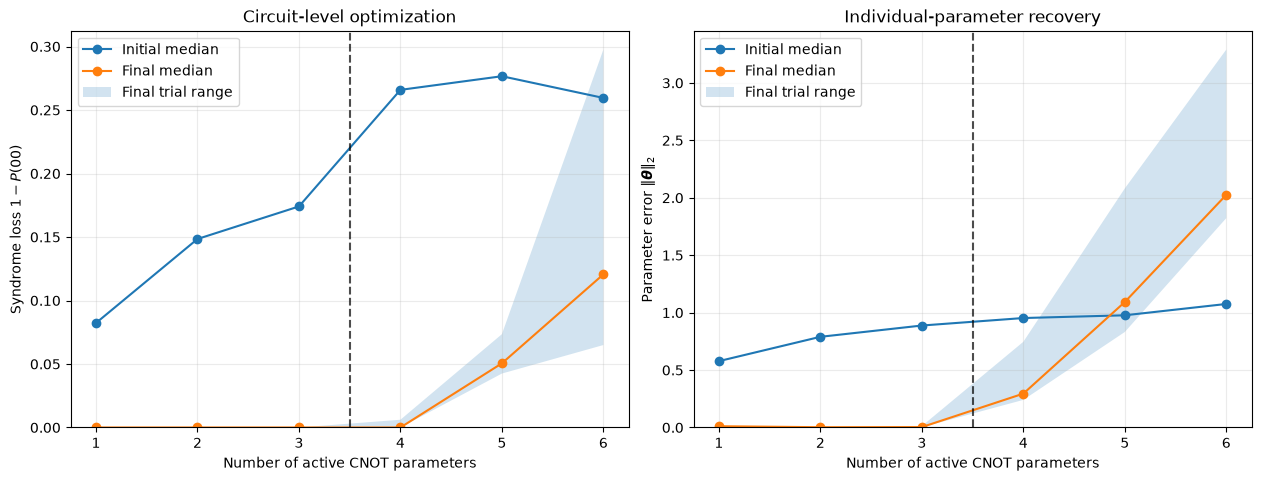

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.7), constrained_layout=True)

x = scaling_summary["active_parameters"].to_numpy()

axes[0].plot(
    x,
    scaling_summary["median_initial_loss"],
    marker="o",
    label="Initial median",
)
axes[0].plot(
    x,
    scaling_summary["median_final_loss"],
    marker="o",
    label="Final median",
)
axes[0].fill_between(
    x,
    scaling_summary["min_final_loss"],
    scaling_summary["max_final_loss"],
    alpha=0.2,
    label="Final trial range",
)
axes[0].axvline(3.5, color="black", linestyle="--", alpha=0.7)
axes[0].set(
    xlabel="Number of active CNOT parameters",
    ylabel=r"Syndrome loss $1-P(00)$",
    title="Circuit-level optimization",
    xticks=x,
)
axes[0].set_ylim(bottom=0)
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(
    x,
    scaling_summary["median_initial_norm"],
    marker="o",
    label="Initial median",
)
axes[1].plot(
    x,
    scaling_summary["median_final_norm"],
    marker="o",
    label="Final median",
)
axes[1].fill_between(
    x,
    scaling_summary["min_final_norm"],
    scaling_summary["max_final_norm"],
    alpha=0.2,
    label="Final trial range",
)
axes[1].axvline(3.5, color="black", linestyle="--", alpha=0.7)
axes[1].set(
    xlabel="Number of active CNOT parameters",
    ylabel=r"Parameter error $\|\boldsymbol{\theta}\|_2$",
    title="Individual-parameter recovery",
    xticks=x,
)
axes[1].set_ylim(bottom=0)
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.show()

The dashed boundary marks where the active-vector dimension first exceeds
the three-dimensional static response space.  Up to three independent
columns, low loss and small parameter error occur together.  Once redundant
columns are added, SPSA can still reduce the circuit-level loss, but the
individual parameter norm becomes seed-dependent and can remain large.

## 5. Inspect a representative all-six-parameter solution

In [10]:
six_parameter_trials = scaling_trials[
    scaling_trials["active_parameters"] == 6
]
best_trial = int(
    six_parameter_trials.sort_values("final_loss").iloc[0]["trial"]
)
six_result = scaling_results[(6, best_trial)]

six_angle_table = pd.DataFrame(
    {
        "gate_id": scaling_order,
        "initial_angle": [
            six_result.initial_angles[gate_id] for gate_id in scaling_order
        ],
        "optimized_angle": [
            six_result.optimized_angles[gate_id] for gate_id in scaling_order
        ],
    }
)

print("Representative trial:", best_trial)
print(f"Initial loss: {six_result.initial_loss:.6f}")
print(f"Final loss:   {six_result.validation_loss:.6f}")
print(
    "Final parameter norm:",
    f"{parameter_l2_norm(six_result.optimized_angles, scaling_order):.6f}",
)
six_angle_table

Representative trial: 1
Initial loss: 0.259521
Final loss:   0.064941
Final parameter norm: 3.290232


,gate_id,initial_angle,optimized_angle
0,enc_01,0.593086,-0.326918
1,syn_0a,-0.487444,-0.410540
2,enc_02,0.425117,-0.341078
3,syn_0b,-0.298534,0.370818
4,syn_1a,0.265004,2.193308
5,syn_1b,-0.476530,-2.342171


## 6. Check downstream recovery for the all-six solution

Low calibration loss is evaluated on the no-error circuit.  We separately
test whether the resulting parameters improve recovery when no error or one
physical bit flip is inserted.

In [11]:
six_recovery_rows = []
for offset, error_qubit in enumerate((None, 0, 1, 2)):
    before_counts = run_parameterized_recovery(
        six_result.initial_angles,
        error_qubit=error_qubit,
        logical_value=0,
        shots=SCALING_VALIDATION_SHOTS,
        seed=5000 + offset,
    )
    after_counts = run_parameterized_recovery(
        six_result.optimized_angles,
        error_qubit=error_qubit,
        logical_value=0,
        shots=SCALING_VALIDATION_SHOTS,
        seed=6000 + offset,
    )
    six_recovery_rows.append(
        {
            "physical_error": "None" if error_qubit is None else f"X{error_qubit}",
            "logical_success_before": logical_success_probability(before_counts, 0),
            "logical_success_after": logical_success_probability(after_counts, 0),
        }
    )

six_recovery_table = pd.DataFrame(six_recovery_rows)
six_recovery_table

,physical_error,logical_success_before,logical_success_after
0,None,0.841553,0.993896
1,X0,0.746338,0.941406
2,X1,0.808350,0.962646
3,X2,0.775635,0.961914


## 7. Reproducible checks

In [12]:
distinct_final_norm = parameter_l2_norm(
    distinct_result.optimized_angles,
    distinct_active,
)

assert full_diagnostics.rank == 3
assert distinct_result.validation_loss < 0.02
assert distinct_final_norm < 0.05
assert degenerate_result.validation_loss < 0.01
assert degenerate_final_norm > 0.5
assert abs(
    sum(degenerate_result.optimized_angles[g] for g in degenerate_active)
) < 0.05
assert scaling_summary["response_rank"].tolist() == [1, 2, 3, 3, 3, 3]
assert (
    scaling_summary["median_final_loss"]
    <= scaling_summary["median_initial_loss"]
).all()
assert scaling_summary.loc[
    scaling_summary["active_parameters"] <= 3,
    "median_final_norm",
].max() < 0.05
assert scaling_summary.loc[
    scaling_summary["active_parameters"] > 3,
    "median_final_norm",
].max() > 0.1

print("Distinct-signature parameter recovery: PASS")
print("Degenerate low-loss/nonzero-parameter example: PASS")
print("One-to-six parameter scaling experiment: PASS")

Distinct-signature parameter recovery: PASS
Degenerate low-loss/nonzero-parameter example: PASS
One-to-six parameter scaling experiment: PASS


## Conclusion

For one, two, and three independently visible parameter directions, SPSA can
simultaneously reduce both syndrome loss and parameter error.  When the
active dimension exceeds the response rank, low syndrome loss no longer
uniquely certifies individual gate calibration.  Redundant parameters can
cancel, drift along flat directions, or converge to different values across
seeds while producing similar syndrome statistics.

This does not establish a universal threshold based only on the number of
syndrome outcomes.  It establishes the correct diagnostic framework:
compare the number of active parameters with the rank and conditioning of
the response generated by the chosen family of calibration experiments.
Additional circuit probes or measurement settings should be introduced only
when they add new independent response directions.